In [6]:
## 2026.02.11 using FineST env
## 2026.02.12 vilization cell type of each ROI
## 2026.03.04 woody_pro:: upload the HE-StarDist embedding and predict the cell type of NCRT_tumor1  
## 2026.03.06 woody_pro:: clearn code 
## 2026.03.13 update cell type level1: nanually make codex_meta_celltype_level1.csv 
## 2026.03.16 use valis to make registration [dont try]
## 2026.03.18 delete two subtypes, adjust scale factor by batch
## 2026.03.19 Train and using NCRT_train.ipynb
## 2026.03.23 Adjust file name and path, then adjust model to use level1 and level2, make model_train_validate.ipynb
## 2026.04.04 woody_pro: SeededNTM; make processing for x, add cv in training for tumor1
## 2026.04.06 Adjust loss function
## 2026.04.14 LLY update using UNI method, based on LOGO CV
## 2026.05.11 Use codex_meta_celltype_level012.csv, run Data_process_visualization.ipynb and demo_level012.sh, 
##            to get he_cell_coords/ and matched_features_tumor1_level012.npz
## 2026.05.11 add the prediction form Level1 directly, and plot AUC
## 2026.06.11 sdd GAT module, learn from histocell, 
##            assume: cells were more likely to belong to the same cell type or cell state 
##            if they are close in proximity within the same tile.            
##            Thus, on the basis of the embedded morphological features, 
##            the graph attention (GAT) block was furtherly applied for topological feature extraction, 
##            expecting that single nuclei could draw attention to its neighboring nuclei. 
## 2026.06.11 back from Xenium, 

In [7]:
import os
# Before other imports: PyTorch/torch.distributed may use /tmp; set NCRT_TMPDIR if quota is tight.
_nrtc_tmp = os.environ.get("NCRT_TMPDIR", os.path.join(os.path.expanduser("~"), "ssd2", "tmp"))
try:
    os.makedirs(_nrtc_tmp, exist_ok=True)
    os.environ["TMPDIR"] = _nrtc_tmp
    os.environ["TEMP"] = _nrtc_tmp
    os.environ["TMP"] = _nrtc_tmp
    import tempfile as _tf_nb
    _tf_nb.tempdir = _nrtc_tmp
except OSError:
    pass

import sys
import importlib
import pandas as pd
from pathlib import Path

## Add the code directory to Python path
path = '/home/lingyu/ssd2/Python/'
code_dir = f'{path}Hist2Pheno/code/Hist2Pheno_pkg/'
if code_dir not in sys.path:
    sys.path.insert(0, code_dir)

## Import (or reload) base module
# Do NOT `import model` — that binds the name ``model`` to the *module* and will shadow
# your trained ``torch.nn.Module`` after ``globals().update(LP)`` when this cell is re-run.
import base
import plot
import model as model_pkg
## Impost：Force reload base.py
importlib.reload(base)
importlib.reload(plot)
importlib.reload(model_pkg)

## Re-import the function (otherwise, still be old_version).
from base import (
    get_celltype_coords,
    divide_into_rois_by_parent,
    get_pixel_size,
    visualize_roi_cells,
    visualize_all_rois_with_he,
    visualize_all_rois,
    extract_and_save_celltype_by_tumorid,
    transformation_matrix_properties,
    invert_transformation_matrix,
    align_pcf_to_he_coordinates,
    add_pixel_coords,
    verify_transformation_alignment,
    merge_coordinates,
    analyze_and_filter_classes_by_gap,
    ImprovedMLPClassifier,
    load_embeddings,
    match_embeddings,
    prepare_matched_embeddings,
    evaluate,
    create_dataloaders,
    train_model,
    CellTypeDataset,
    evaluate_and_plot_on_all_data,
    align_matrix,
    match_StarCoords2ROI,
    match_celltype2stardist,
    merge_celltype_level12,
    make_PCF2HE_alignment,
    load_cell_pixcoords,load_hist_embeddings,
    match_hist2cell_matrix,
    make_PCF2HE2StarDist_alignment,
    save_hce_validation_metrics,
    split_train_test,
    prepare_data_leave_one_group_out,
    spatial_tile_groups_for_logo,
    loader_train_test,
    first_pth_tensor,
    build_spatial_neighbor_index,
)

from plot import (
    plot_celltype_distribution,
    visualize_all_celltype_distributions,
    plot_celltype_distribution,
    plot_celltype_spatial_distribution,
    plot_PCF_HE_counts,
    plot_WSI_counts,
    plot_cell_area_histogram,
    plot_confusion_matrix,
    plot_level1_spatial_distribution,
    plot_per_class_f1,
    plot_per_class_accuracy,
    plot_level1_accuracy_from_level2_predictions,
    mlp_collect_softmax_probs,
    plot_multiclass_roc_curves,
    plot_level1_roc_from_level2_scores,
    plot_level1_f1_from_level2_predictions,
    plot_level1_accuracy_from_level1_head,
    plot_level1_f1_from_level1_head,
    plot_level1_roc_from_level1_head
)

from model import (
    build_mlp_classifier,
    get_best_checkpoint_path,
    sync_best_mlp_from_logo_fold,
    train_and_save_model,
    infer_input_dim_and_num_classes,
    mode_validation,
    load_model_for_predict,
    train_and_save_model_from_split,
    mode_validation_from_split,
    train_hce_leave_one_group_out_cv,
    run_logo_cv_and_load_best_model,
    report_logo_cv_means_and_insample_eval,
    run_logo_cv_with_insample_report,
    run_stratified_kfold_cv_with_insample_report
)

## Import HAS_OPENSLIDE and HAS_TIFFFILE from base module for use in notebook
HAS_OPENSLIDE = base.HAS_OPENSLIDE
HAS_TIFFFILE = base.HAS_TIFFFILE

## Also import openslide module if available (needed for direct use in some cells)
if HAS_OPENSLIDE:
    import openslide
else:
    openslide = None

try:
    import tifffile
except ImportError:
    tifffile = None

print("Successfully reloaded functions from base.py")
print(f"openslide: {HAS_OPENSLIDE}, tifffile: {HAS_TIFFFILE}")


## reset pathway
os.chdir(f'{path}Hist2Pheno/data/CODEX/ESCC')
therapy_data = 'NCRT'
image_feature = f'sc_{therapy_data}'
# therapy_model = f'{therapy_data}_project_tumor1'
# therapy_model = f'{therapy_data}_project_tumor1_UNI'
therapy_model = f'{therapy_data}_project_tumor1_UNI_GAT'
segment_data1 = f'{therapy_data}_project - seg 1-14'
segment_data2 = f'{therapy_data}_project - seg 15-28'
export_data = 'export'
save_result = 'result'

stardist_data = 'StarDist_Segment'
transfer_data = 'he_cell_coords'
qupath_corner = 'QupathCorners'
# Spatial / GAT-lite config (HistoCell-style neighbor fusion before MLP)
USE_SPATIAL_CONTEXT = True
SPATIAL_K = 8
SPATIAL_MODE = "mean"  # or "attention"
AB_CKPT_SUBDIR = "ablation_kfold_ckpts_012_GAT"


Successfully reloaded functions from base.py
openslide: False, tifffile: True


In [8]:
## CUDA/CPU sanity check for training setup
import os
import sys
import torch

# Default physical GPU index 2 (torch device string cuda:2). Override without editing:
#   export NCRT_CUDA_DEVICE=0
CUDA_DEVICE_INDEX = int(os.environ.get("NCRT_CUDA_DEVICE", "0"))

print(sys.executable)
print(
    f"torch {torch.__version__} | built with CUDA: {torch.version.cuda} | "
    f"cuda.is_available: {torch.cuda.is_available()}"
)

if torch.cuda.is_available():
    n_gpu = torch.cuda.device_count()
    if CUDA_DEVICE_INDEX < 0 or CUDA_DEVICE_INDEX >= n_gpu:
        raise RuntimeError(
            f"CUDA_DEVICE_INDEX={CUDA_DEVICE_INDEX} out of range; only {n_gpu} GPU(s) visible."
        )
    torch.cuda.set_device(CUDA_DEVICE_INDEX)
    device = torch.device(f"cuda:{CUDA_DEVICE_INDEX}")
    # Reproducibility-first: use deterministic cuDNN settings.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    amp_scaler = torch.amp.GradScaler("cuda")  # AMP only on CUDA
    print(
        f"Using device cuda:{CUDA_DEVICE_INDEX} | "
        f"{torch.cuda.get_device_name(CUDA_DEVICE_INDEX)}"
    )
else:
    allow_cpu = os.environ.get("NCRT_ALLOW_CPU_TRAIN", "").strip().lower() in ("1", "true", "yes")
    if allow_cpu:
        device, amp_scaler = torch.device("cpu"), None
        print("WARNING: CUDA unavailable, training on CPU (set NCRT_ALLOW_CPU_TRAIN=1).")
    else:
        raise RuntimeError(
            "CUDA unavailable. Please use a CUDA-enabled PyTorch build, "
            "or set NCRT_ALLOW_CPU_TRAIN=1 to run on CPU."
        )

if device.type == "cuda":
    print(f"device: {device} | {torch.cuda.get_device_name(CUDA_DEVICE_INDEX)}")
else:
    print(f"device: {device}")



## Reproducibility setup (run this first after kernel restart)
import os
import random
import numpy as np
import torch

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
# Needed by CUDA for deterministic GEMM on some ops.
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Enforce deterministic behavior (may reduce speed).
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

print(f"Reproducibility configured with SEED={SEED}")

/ssd2/users/lingyu/conda_envs/SeededNTM/bin/python
torch 2.9.1+cu130 | built with CUDA: 13.0 | cuda.is_available: True
Using device cuda:0 | NVIDIA RTX PRO 6000 Blackwell Server Edition
device: cuda:0 | NVIDIA RTX PRO 6000 Blackwell Server Edition
Reproducibility configured with SEED=42


In [9]:
hist_embedding_dir = Path(
    f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/ImgEmbeddings_tumor1/sc_pth_16_16'
)
tensor = first_pth_tensor(hist_embedding_dir)


Found file: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/NCRT_project_tumor1_UNI_GAT/ImgEmbeddings_tumor1/sc_pth_16_16/sc_NCRT_8581.601852334961_4044.732986963536.pth
Loaded type: <class 'tuple'>
tensor.shape of the first .pth file: torch.Size([1, 1, 1024])


/home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/ESCC/NCRT/NCRT_project_tumor1/ImgEmbeddings_tumor1/sc_pth_16_16/sc_NCRT_8581.601852334961_4044.732986963536.pth

<class 'tuple'>

torch.Size([1, 1, 384])

## Cell Type Classification Model

Leave-one-group-out (LOGO) CV (sklearn `LeaveOneGroupOut` idea).  
Uses npz `matched_features_tumor1_logo.npz` with a `TumorID` column when available. If that column is constant for all rows (typical for tumor1-only CSV), the notebook **falls back to spatial tiles** on `X_pix_HE`×`Y_pix_HE` (`spatial_tile_groups_for_logo`).

In [10]:
## Match embeddings with celltype data by coordinates (stratified_kfold path)
cell_coords_path = f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/{therapy_data}_CellPixCoords_tumor1.csv'
hist_embedding_dir = Path(
    f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/ImgEmbeddings_tumor1/sc_pth_16_16'
)
matched_features_path = (
    f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/matched_features_tumor1_level012.npz'
)

level1_name = "celltype_level1"
match_tolerance = 1.0
X, y, y_level1, y_level0, y_level01, y_level12, X_coords_matched = match_hist2cell_matrix(
    cell_coords_path=cell_coords_path,
    hist_embedding_dir=hist_embedding_dir,
    matched_features_path=matched_features_path,
    coord_cols=('X_pix_HE', 'Y_pix_HE'),
    tolerance=match_tolerance,
    pth_prefix=image_feature,
    level1_name=level1_name,
)

if X_coords_matched is not None:
    print(f"Matched coordinates shape: {X_coords_matched.shape}")


Loading celltype Ground Truth ...
  Loaded 80303 cells
  Cell types: 40 unique types

  ✓ matched_features cache found; skipping .pth directory load.
Loading pre-saved matched data...
  ✓ Loaded from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/NCRT_project_tumor1_UNI_GAT/matched_features_tumor1_level012.npz

Data shape:
  X alignment: 80303 rows
  y (L2 / celltype): (80303,), 40 classes
  y_level1 (lineage): (80303,), 7 classes
  y_level12 (sublineage): (80303,), 12 classes
  y_level3 (CNiche): (80303,), 4 classes
  y_level4 (TNiche): (80303,), 6 classes
  ✓ Coordinates found in saved data
  ✓ Coordinates loaded: (80303, 2)
Matched coordinates shape: (80303, 2)


In [11]:
# Reuse LOGO filtering/encoding path as stratified_kfold prep; groups are placeholders here.
import numpy as np
from sklearn.preprocessing import StandardScaler

cv_data = prepare_data_leave_one_group_out(
    X, y, y_level1,
    groups=np.arange(X.shape[0], dtype=np.int64),
    X_coords=X_coords_matched,
)

class_names = cv_data["class_names"]
class_names_level1 = cv_data["class_names_level1"]
le_level2 = cv_data["le_level2"]
le_level1 = cv_data["le_level1"]

scaler = StandardScaler()
scaler.fit(cv_data["X_f"])

# Coordinates aligned with filtered rows (same mask as rare-L2 filtering)
X_coords_plot = (
    cv_data.get("X_coords_f")
    if cv_data.get("X_coords_f") is not None
    else (X_coords_matched[cv_data["mask"]] if X_coords_matched is not None else None)
)

# Optional: single random 70/30 split for comparison (disabled in CV flow)
RUN_RANDOM_TRAIN_TEST_SPLIT = False
if RUN_RANDOM_TRAIN_TEST_SPLIT:
    result = split_train_test(X, y, y_level1)
else:
    result = None



Leave-one-group-out prep (filtered data):
  Samples: 80302, features: 1024
  Level2 classes: 39, Level1 classes: 7
  Coordinates: (80302, 2)
  Groups (for LOGO): 80302 unique


In [12]:
# LOGO：训练与评估由 ``run_logo_cv_with_insample_report`` / ``train_hce_leave_one_group_out_cv`` 内部构建 DataLoader。
# If you set RUN_RANDOM_TRAIN_TEST_SPLIT=True above, uncomment:
# loaders = loader_train_test(result, seed=SEED, train_balance_sampler=False)

loaders = None
train_loader = val_loader = val_loader_eval = None
train_dataset = val_dataset = None
X_train_scaled = y_train_encoded = y_test_encoded = None
y_train_level1_encoded = y_test_level1_encoded = None
y_encoded_f = cv_data["y_encoded_f"]
y_level1_encoded_f = cv_data["y_level1_encoded_f"]

## MLP classifier

In [ ]:
# Ablation: unified HCE weights under stratified_kfold CV (GAT / spatial context enabled)
import os
import shutil
import pandas as pd

KFOLD_RESUME_FROM_CHECKPOINTS = True  # GAT ckpts live under ablation_kfold_ckpts_012_GAT
AB_PATIENCE = 10
AB_MAX_EPOCHS = 50
AB_HIDDEN_DIMS = (1024, 512, 256)    # Model default
AB_CV_K = 5
AB_STRATIFY_TARGET = "joint"  # choices: level2 / level1 / joint

print(
    f"GAT training: use_spatial_context={USE_SPATIAL_CONTEXT}, "
    f"k={SPATIAL_K}, mode={SPATIAL_MODE!r}, ckpt_subdir={AB_CKPT_SUBDIR}"
)

ABLATION_CONFIGS = [
    {"tag": "D_emph_L2", "hce_w1": 1.0, "hce_w2": 2.0, "hce_w12": 1.0},
]

ablation_runs = {}
rows = []

for cfg in ABLATION_CONFIGS:
    tag = cfg["tag"]
    ckpt_dir = os.path.join(
        path,
        "Hist2Pheno/data/CODEX/ESCC",
        therapy_data,
        therapy_model,
        AB_CKPT_SUBDIR,
        tag,
    )
    print("\n" + "=" * 80)
    print(f"[Ablation][stratified_kfold][GAT] Running: {tag}")
    print("=" * 80)

    LP_i = run_stratified_kfold_cv_with_insample_report(
        device=device,
        cv_data=cv_data,
        scaler=scaler,
        class_names=class_names,
        evaluate=evaluate,
        path=path,
        therapy_data=therapy_data,
        therapy_model=therapy_model,
        hce_w1=cfg["hce_w1"],
        hce_w2=cfg["hce_w2"],
        hce_w12=cfg["hce_w12"],
        n_splits=AB_CV_K,
        stratify_target=AB_STRATIFY_TARGET,
        patience=AB_PATIENCE,
        max_epochs=AB_MAX_EPOCHS,
        loader_kwargs={"seed": SEED, "train_balance_sampler": False},
        resume_from_checkpoints=KFOLD_RESUME_FROM_CHECKPOINTS,
        kfold_checkpoint_dir=ckpt_dir,
        hidden_dims=AB_HIDDEN_DIMS,
        use_spatial_context=USE_SPATIAL_CONTEXT,
        spatial_k=SPATIAL_K,
        spatial_mode=SPATIAL_MODE,
    )

    ablation_runs[tag] = LP_i
    score_l4 = float(
        LP_i["val_macro_f1"]
        + LP_i["val_weighted_f1"]
        + LP_i["val_level1_macro_f1"]
        + LP_i["val_level1_weighted_f1"]
    )
    rows.append(
        {
            "tag": tag,
            "hce_w1": cfg["hce_w1"],
            "hce_w2": cfg["hce_w2"],
            "hce_w12": cfg["hce_w12"],
            "hidden_dims": str(AB_HIDDEN_DIMS),
            "spatial_k": SPATIAL_K,
            "spatial_mode": SPATIAL_MODE,
            "l2_acc": float(LP_i["val_acc"]),
            "l2_macro_f1": float(LP_i["val_macro_f1"]),
            "l2_weighted_f1": float(LP_i["val_weighted_f1"]),
            "l1_acc": float(LP_i["val_level1_acc"]),
            "l1_macro_f1": float(LP_i["val_level1_macro_f1"]),
            "l1_weighted_f1": float(LP_i["val_level1_weighted_f1"]),
            "best_epoch": int(LP_i["best_epoch"]),
            "l4_kfold_select_score": score_l4,
        }
    )

AB_SUMMARY_DF = (
    pd.DataFrame(rows)
    .sort_values("l4_kfold_select_score", ascending=False)
    .reset_index(drop=True)
)
print("\nAblation summary (sorted by l4_kfold_select_score = L2/L1 macro+weighted):")
display(AB_SUMMARY_DF)

best_tag = AB_SUMMARY_DF.iloc[0]["tag"]
LP = ablation_runs[best_tag]

best_idx = AB_SUMMARY_DF["l4_kfold_select_score"].astype(float).idxmax()
assert AB_SUMMARY_DF.iloc[best_idx]["tag"] == best_tag

best_cfg = next(c for c in ABLATION_CONFIGS if c["tag"] == best_tag)
best_fold = LP["best_fold"]
best_fold_4term_score = float(
    best_fold["l2_macro_f1"]
    + best_fold["l2_weighted_f1"]
    + best_fold["l1_macro_f1"]
    + best_fold["l1_weighted_f1"]
)

print(f"Selected best config by l4_kfold_select_score: {best_tag}")
print(
    "  Best weights: "
    f"hce_w1={best_cfg['hce_w1']}, hce_w2={best_cfg['hce_w2']}, hce_w12={best_cfg['hce_w12']}"
)
print(
    "  Best fold checkpoint in selected config: "
    f"fold={best_fold['fold']}, 4-term score={best_fold_4term_score:.4f}, path={best_fold['checkpoint']}"
)

sync_best_mlp_from_logo_fold(
    path,
    therapy_data,
    therapy_model,
    best_fold["checkpoint"],
)
print(f"  Synced best_mlp_gpu.pt: {get_best_checkpoint_path(path, therapy_data, therapy_model)}")

# Neighbor index for spatial inference on filtered HE cells
neighbor_index_he = LP.get("spatial_neighbor_index")
if neighbor_index_he is None and USE_SPATIAL_CONTEXT and X_coords_plot is not None:
    neighbor_index_he = build_spatial_neighbor_index(X_coords_plot, k_neighbors=SPATIAL_K)
    print(f"Built neighbor_index_he: {np.asarray(neighbor_index_he).shape}")

globals().update(LP)
globals()["AB_SUMMARY_DF"] = AB_SUMMARY_DF
globals()["neighbor_index_he"] = neighbor_index_he


In [ ]:
# ## Optional single-run template (disabled by default)
# # 已在上一单元完成 ablation，并将最优配置结果写入 LP。
# # 若你只想单独重跑某个配置，可把 RUN_SINGLE = True 后执行本单元。

# RUN_SINGLE = False
# if RUN_SINGLE:
#     LOGO_RESUME_FROM_CHECKPOINTS = None
#     LP = run_logo_cv_with_insample_report(
#         device=device,
#         cv_data=cv_data,
#         scaler=scaler,
#         class_names=class_names,
#         evaluate=evaluate,
#         path=path,
#         therapy_data=therapy_data,
#         therapy_model=therapy_model,
#         hce_w1=1.0,
#         hce_w2=1.0,
#         hce_w12=1.0,
#         patience=10,
#         max_epochs=50,
#         hidden_dims=(768, 384, 192),
#         loader_kwargs={"seed": SEED, "train_balance_sampler": False},
#         resume_from_checkpoints=LOGO_RESUME_FROM_CHECKPOINTS,
#     )
#     globals().update(LP)
# else:
#     print("RUN_SINGLE=False: keep LP from ablation-best config in previous cell.")

混淆矩阵里的 val_preds_level1 
- = 从 L2 predict（softmax）经层次加总矩阵得到的 L1 预测，不是「L1 独立 head 的直接分类」。
- 若要看 level1_head 自己的混淆矩阵，需要改成用 forward_heads 取 logits_l1 再 argmax（当前 LP 这条路径没有存那份预测）。

Computing confusion matrix...


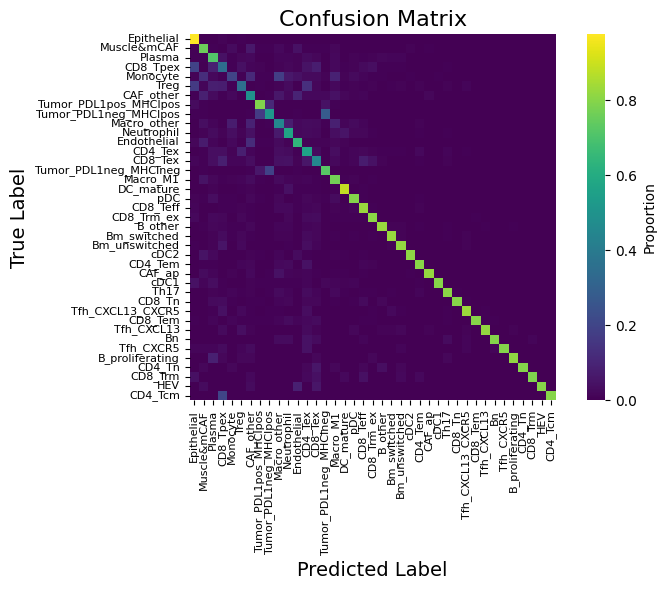

Computing confusion matrix...


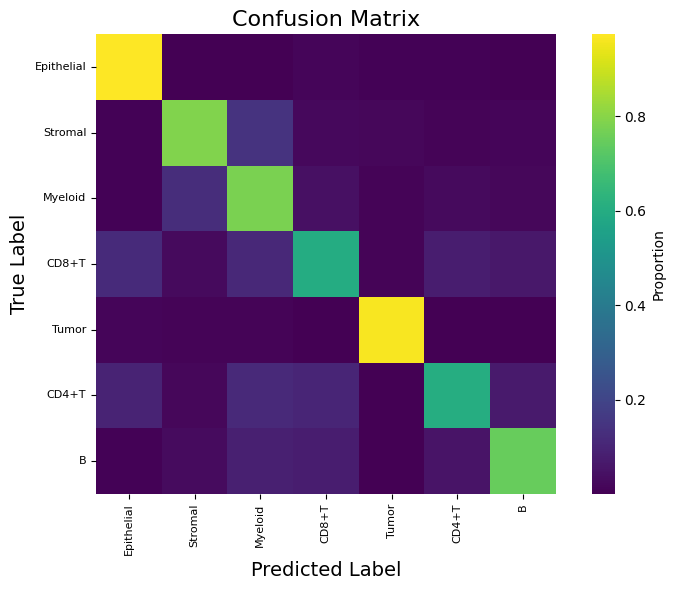

In [9]:
# Level2 confusion matrix
plot_confusion_matrix(
    val_labels,
    val_preds,
    class_names,
    # save_path=f'{therapy_data}/{therapy_model}/{save_result}/conf_matrix_tumor1_level2_hce.pdf',
    save_path=None
)

# Level1 confusion matrix
plot_confusion_matrix(
    val_labels_level1,
    val_preds_level1,
    class_names_level1,
    # save_path=f'{therapy_data}/{therapy_model}/{save_result}/conf_matrix_tumor1_level1_hce.pdf',
    save_path=None
)

In [ ]:
# Level2 confusion matrix
plot_confusion_matrix(
    val_labels,
    val_preds,
    class_names,
    # save_path=f'{therapy_data}/{therapy_model}/{save_result}/conf_matrix_tumor1_level2_hce.pdf',
    save_path=None
)

# Level1 confusion matrix (from L2 softmax aggregated to L1; see model.report_logo_cv_means_and_insample_eval)
plot_confusion_matrix(
    val_labels_level1,
    val_preds_level1,
    class_names_level1,
    # save_path=f'{therapy_data}/{therapy_model}/{save_result}/conf_matrix_tumor1_level1_hce.pdf',
    save_path=None
)

# Optional: dedicated L1-head predictions (same LP run); safe if name not in globals yet
_val_l1_head = globals().get("val_preds_level1_head")
if _val_l1_head is None and isinstance(globals().get("LP"), dict):
    _val_l1_head = LP.get("val_preds_level1_head")
if _val_l1_head is not None:
    print("L1 agg vs L1 head agreement:", float((val_preds_level1 == _val_l1_head).mean()))
    plot_confusion_matrix(
        val_labels_level1,
        _val_l1_head,
        class_names_level1,
        # save_path=f'{therapy_data}/{therapy_model}/{save_result}/conf_matrix_tumor1_level1_hce_head.pdf',
        save_path=None,
    )
else:
    print(
        "Skip L1-head confusion matrix: val_preds_level1_head missing — importlib.reload(model) "
        "then re-run the CV/ablation cell (globals().update(LP))."
    )


In [12]:
## Save validation metrics (row = LOGO mean over folds; acc columns are NaN)
import numpy as np

metrics_csv_path = f"{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/{save_result}/hce_validation_metrics.csv"

hce_w1_used = globals().get("hce_w1", 1.0)
hce_w2_used = globals().get("hce_w2", 1.0)
hce_w12_used = globals().get("hce_w12", 2.0)
mean_best_epoch = int(round(float(np.mean([f["best_epoch"] for f in logo_summary["folds"]]))))

metrics_df, combined_df = save_hce_validation_metrics(
    val_acc=float("nan"),
    val_macro_f1=logo_summary["l2_macro_f1_mean"],
    val_weighted_f1=logo_summary["l2_weighted_f1_mean"],
    val_level1_acc=float("nan"),
    val_level1_macro_f1=logo_summary["l1_macro_f1_mean"],
    val_level1_weighted_f1=logo_summary["l1_weighted_f1_mean"],
    class_names=class_names if "class_names" in globals() else None,
    class_names_level1=class_names_level1 if "class_names_level1" in globals() else None,
    best_epoch=mean_best_epoch,
    hce_lambda=None,
    hce_w1=hce_w1_used,
    hce_w2=hce_w2_used,
    hce_w12=hce_w12_used,
    therapy_data=f"{therapy_data}_tumor1_LOGO",
    metrics_csv_path=metrics_csv_path,
    # metrics_csv_path=None,
)

Current run metrics:
             timestamp      therapy_data  best_epoch hce_lambda  hce_w1  \
0  2026-05-12 15:28:23  NCRT_tumor1_LOGO           0       None     1.0   

   hce_w2  hce_w12  val_l2_accuracy  val_l2_macro_f1  val_l2_weighted_f1  \
0     2.0      1.0              NaN         0.174842            0.441593   

   val_l1_accuracy  val_l1_macro_f1  val_l1_weighted_f1  num_l2_classes  \
0              NaN         0.555036            0.593619              39   

   num_l1_classes  
0               7  

Saved comparison table to: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/NCRT_project_tumor1_UNI/result/hce_validation_metrics.csv
Total rows: 3


Visualizing per-class performance...
  ✓ Computed metrics for 39 classes
Figure saved to NCRT/NCRT_project_tumor1_UNI/result/f1_per_class_tumor1_level2_hce.pdf


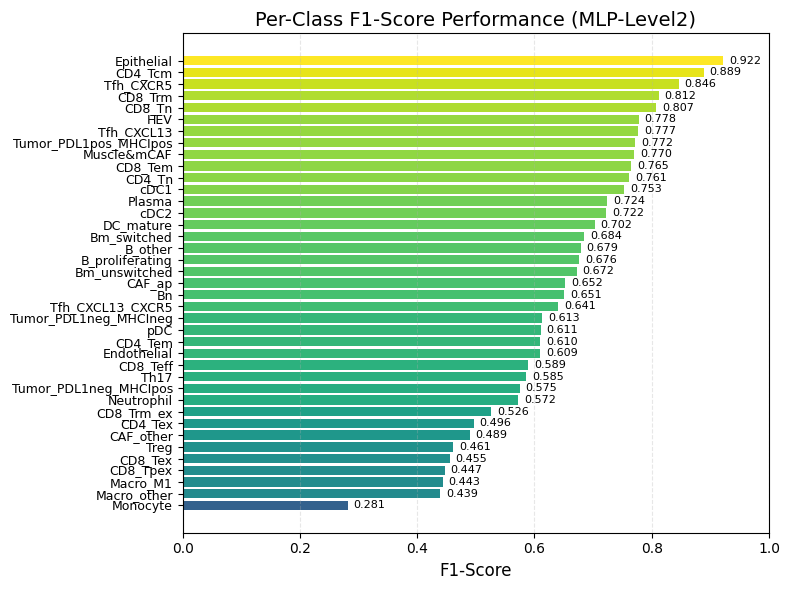


Model Summary:
  Device: cuda:2
  Total classes (before filtering): 39
  Actual classes in test set: 39
  Feature dimension: 1024
  Model parameters: 1,721,134
  Best epoch: 0
  Test Accuracy: 0.6548
  Test Macro F1: 0.6477
  Test Weighted F1: 0.6426
Visualizing per-class performance...
  ✓ Computed metrics for 7 classes
Figure saved to NCRT/NCRT_project_tumor1_UNI/result/f1_per_class_tumor1_level1_hce.pdf


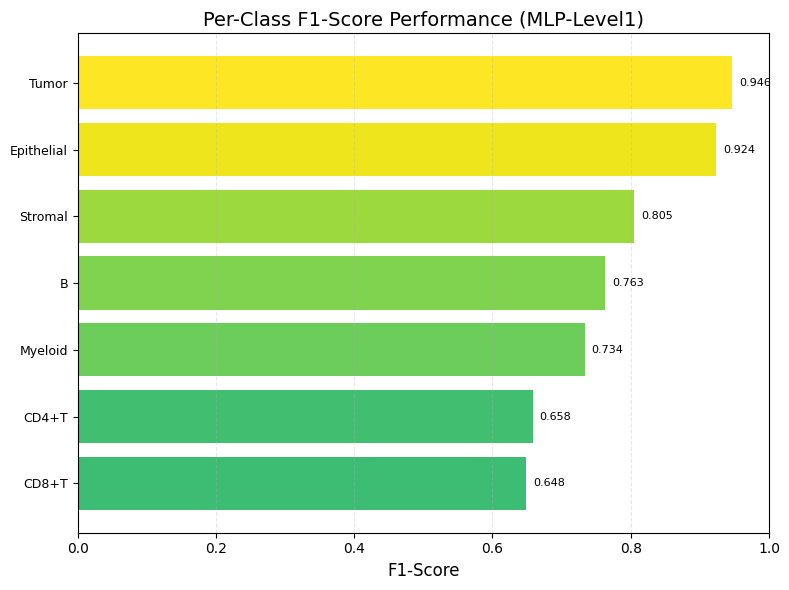


Model Summary:
  Device: cuda:2
  Total classes (before filtering): 7
  Actual classes in test set: 7
  Feature dimension: 1024
  Model parameters: 1,721,134
  Best epoch: 0
  Test Accuracy: 0.7997
  Test Macro F1: 0.7826
  Test Weighted F1: 0.7961
Visualizing per-class performance...
  ✓ Computed metrics for 7 classes
Figure saved to NCRT/NCRT_project_tumor1_UNI/result/f1_per_class_tumor1_level1head_hce.pdf


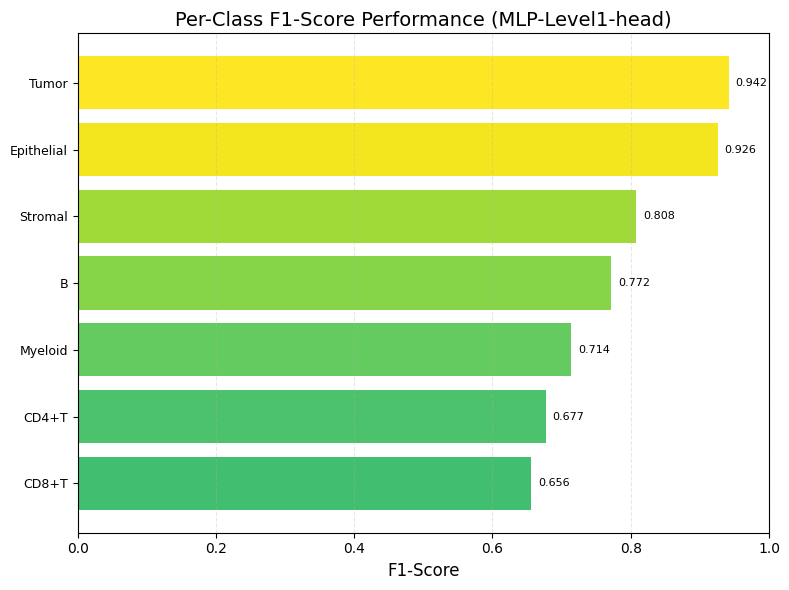


Model Summary:
  Device: cuda:2
  Total classes (before filtering): 7
  Actual classes in test set: 7
  Feature dimension: 1024
  Model parameters: 1,721,134
  Best epoch: 0
  Test Accuracy: 0.7997
  Test Macro F1: 0.7826
  Test Weighted F1: 0.7961


In [ ]:
# Per-class F1 for level2
metrics_df_level2 = plot_per_class_f1(
    val_labels,
    val_preds,
    class_names,
    model=model,
    device=device,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    input_dim=input_dim,
    best_epoch=best_epoch,
    test_acc=val_acc,
    test_macro_f1=val_macro_f1,
    test_weighted_f1=val_weighted_f1,
    model_name="MLP-Level2",
    y_sort_by="f1_asc",
    # save_path=f'{therapy_data}/{therapy_model}/{save_result}/f1_per_class_tumor1_level2_hce.pdf',
    save_path=None
)

# Per-class F1 for level1
metrics_df_level1 = plot_per_class_f1(
    val_labels_level1,
    val_preds_level1,
    class_names_level1,
    model=model,
    device=device,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    input_dim=input_dim,
    best_epoch=best_epoch,
    test_acc=val_level1_acc,
    test_macro_f1=val_level1_macro_f1,
    test_weighted_f1=val_level1_weighted_f1,
    model_name="MLP-Level1",
    y_sort_by="f1_asc",
    # save_path=f'{therapy_data}/{therapy_model}/{save_result}/f1_per_class_tumor1_level1_hce.pdf',
    save_path=None
)

# Per-class F1 for level1
metrics_df_level1 = plot_per_class_f1(
    val_labels_level1,
    val_preds_level1_head,
    class_names_level1,
    model=model,
    device=device,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    input_dim=input_dim,
    best_epoch=best_epoch,
    test_acc=val_level1_acc,
    test_macro_f1=val_level1_macro_f1,
    test_weighted_f1=val_level1_weighted_f1,
    model_name="MLP-Level1-head",
    y_sort_by="f1_asc",
    # save_path=f'{therapy_data}/{therapy_model}/{save_result}/f1_per_class_tumor1_level1head_hce.pdf',
    save_path=None
)

In [ ]:
## Evaluate on all data and plot spatial distribution
# Skip loading npz here: rows must match ``cv_data`` filter and ``scaler`` fit on ``X_f``.
all_acc, all_macro_f1, all_weighted_f1, all_preds, all_labels = evaluate_and_plot_on_all_data(
    model=model,
    matched_features_path="",
    class_names=class_names,
    evaluate=evaluate,
    plot_celltype_spatial_distribution=plot_celltype_spatial_distribution,
    CellTypeDataset=CellTypeDataset,
    device=device,
    scaler=scaler,
    val_loader=val_loader if "val_loader" in globals() else None,
    X=cv_data["X_f"],
    y=None,
    y_encoded=cv_data["y_encoded_f"],
    X_train=None,
    X_train_scaled=X_train_scaled if "X_train_scaled" in globals() else None,
    X_test_scaled=X_test_scaled if "X_test_scaled" in globals() else None,
    y_train_encoded=y_train_encoded if "y_train_encoded" in globals() else None,
    y_test_encoded=y_test_encoded if "y_test_encoded" in globals() else None,
    min_samples_per_class=min_samples_per_class if "min_samples_per_class" in globals() else 29,
    X_coords_matched=X_coords_plot if "X_coords_plot" in globals() else None,
    neighbor_index=neighbor_index_he if "neighbor_index_he" in globals() else None,
    celltype_pixel_NCRT_tumor1=celltype_pixel_NCRT_tumor1 if "celltype_pixel_NCRT_tumor1" in globals() else None,
)


  Level1 spatial plot: using distinct palette for 7 class name(s).
Number of valid data points: 80302
Number of cell types: 7


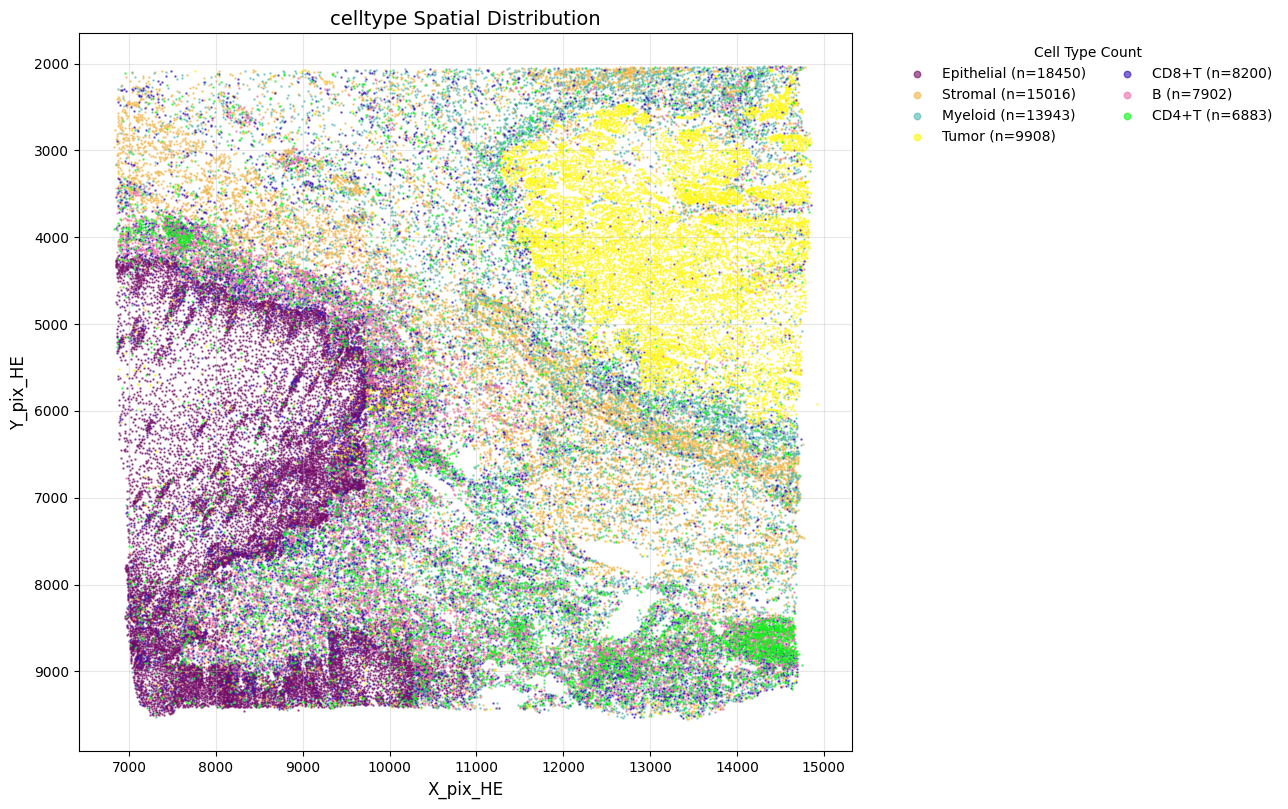

Number of valid data points: 80302
Number of cell types: 7


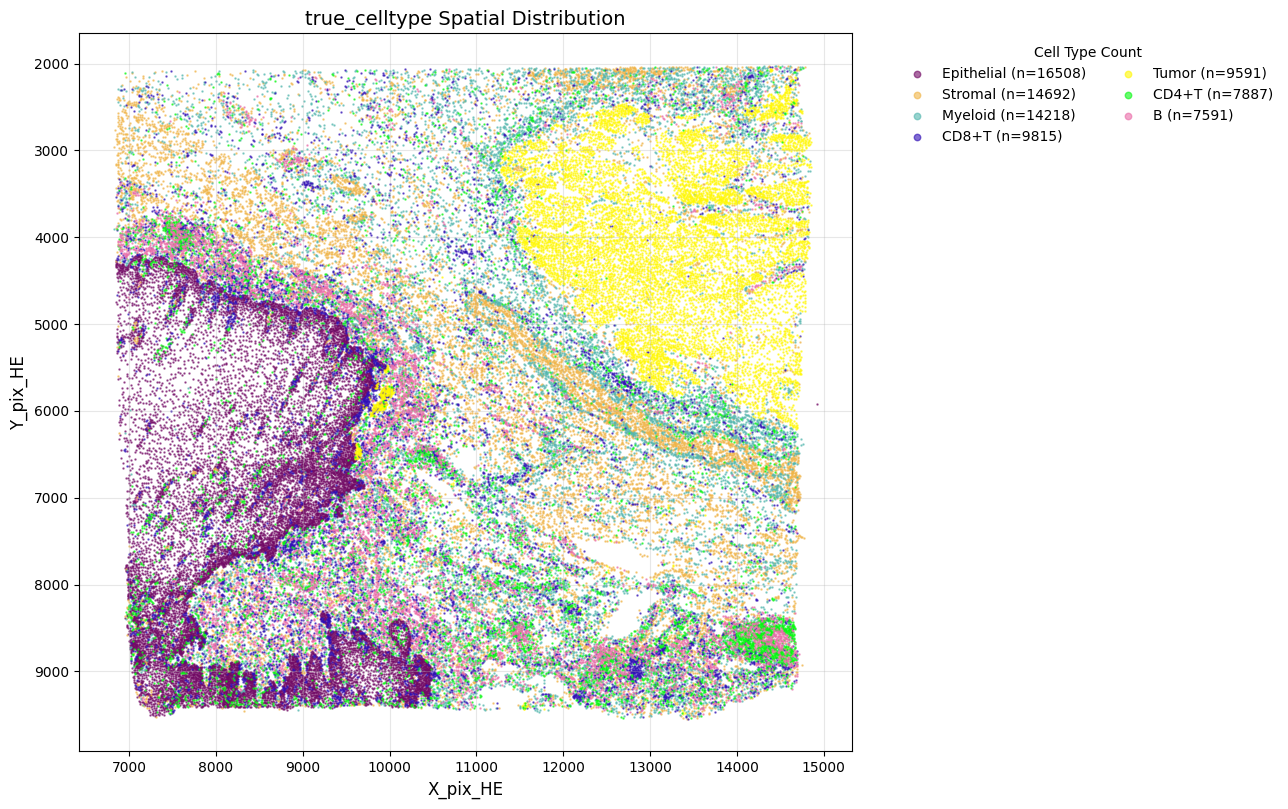

In [18]:
# save_path_pred = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/{save_result}/celltype_valid_tumor1_level1_hce.jpg'
# save_path_true = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/{save_result}/celltype_true_tumor1_level1_hce.jpg'
plot_level1_spatial_distribution(
    matched_features_path=matched_features_path,
    all_preds=all_preds,
    class_names_level1=class_names_level1,
    class_names=class_names,
    y_encoded_f=y_encoded_f,
    y_level1_encoded_f=y_level1_encoded_f,
    plot_celltype_spatial_distribution=plot_celltype_spatial_distribution,
    # save_path_pred=save_path_pred,
    # save_path_true=save_path_true
)

## Predict StarDist

In [19]:
## Load best model for StarDist prediction.
model_star = load_model_for_predict(path, therapy_data, therapy_model, parent_dir=True)

Loading best model for StarDist prediction...
  Checkpoint file: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/NCRT_project_tumor1_UNI/best_mlp_gpu.pt
  Inferred hidden_dims from checkpoint: [1024, 512, 256]
✓ StarDist model loaded


In [ ]:
## Tumor1 StarDist (NCRT_project_tumor1_UNI_GAT)
celltype_pixel_NCRT_stardist_path = (
    f'{path}Hist2Pheno/data/CODEX/ESCC/{transfer_data}/{therapy_data}_CellPixCoords_tumor1_StarDist.csv'
)
embedding_star_dir = Path(
    f"{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/ImgEmbeddings_tumor1_stardist/sc_pth_16_16"
)
matched_features_star_path = (
    f"{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/matched_features_tumor1_stardist012.npz"
)

level1_name = globals().get("level1_name", "celltype_level1")
match_tolerance = 1.0
X_star, y_star, y_star_level1, y_star_level0, y_star_level01, y_star_level12, X_coords_star = match_hist2cell_matrix(
    cell_coords_path=celltype_pixel_NCRT_stardist_path,
    hist_embedding_dir=embedding_star_dir,
    matched_features_path=matched_features_star_path,
    coord_cols=("centroid_x", "centroid_y"),
    tolerance=match_tolerance,
    pth_prefix=f"sc_{therapy_data}",
    level1_name=level1_name,
)

import numpy as np

neighbor_index_star = None
if getattr(model_star, "use_spatial_context", False) and X_coords_star is not None:
    neighbor_index_star = build_spatial_neighbor_index(X_coords_star, k_neighbors=SPATIAL_K)
    print(f"Built neighbor_index_star: {np.asarray(neighbor_index_star).shape}")


In [ ]:
# Predict on StarDist-matched data and plot spatial distribution (level2 + level1).
class_names_star = class_names if "class_names" in globals() and class_names is not None else [
    str(i) for i in range(num_classes_star)
]

all_acc, all_macro_f1, all_weighted_f1, all_preds, all_labels = evaluate_and_plot_on_all_data(
    model=model_star,
    matched_features_path=matched_features_star_path,
    class_names=class_names_star,
    evaluate=evaluate,
    plot_celltype_spatial_distribution=plot_celltype_spatial_distribution,
    CellTypeDataset=CellTypeDataset,
    device=device,
    scaler=scaler,
    val_loader=None,
    prediction_only=True,
    X_coords_matched=X_coords_star if "X_coords_star" in globals() else None,
    neighbor_index=neighbor_index_star if "neighbor_index_star" in globals() else None,
    celltype_pixel_NCRT_tumor1=celltype_pixel_NCRT_stardist if "celltype_pixel_NCRT_stardist" in globals() else None,
)


  Level1 spatial plot: using distinct palette for 7 class name(s).
Number of valid data points: 77996
Number of cell types: 7
Number of valid data points: 77996
Number of cell types: 7
Saved StarDist level1 predicted/true spatial plots.


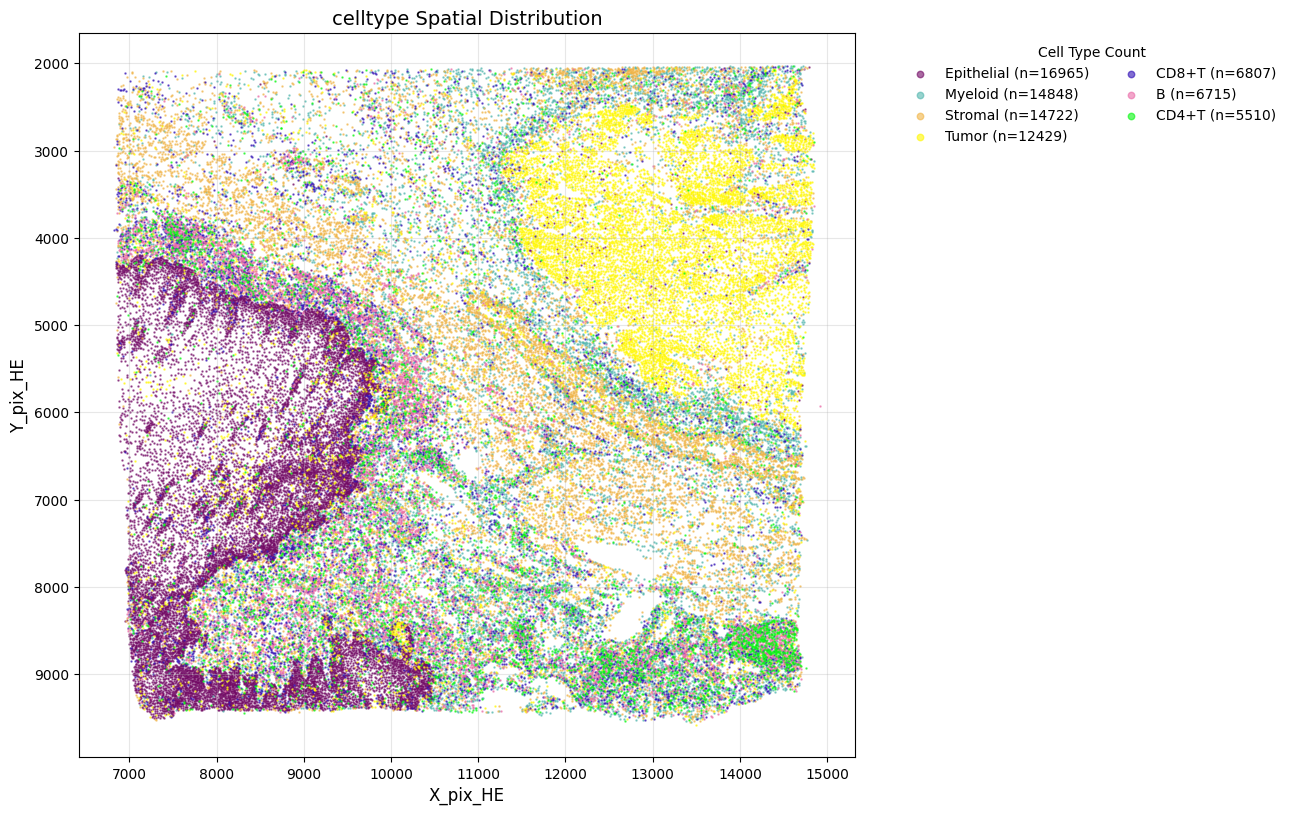

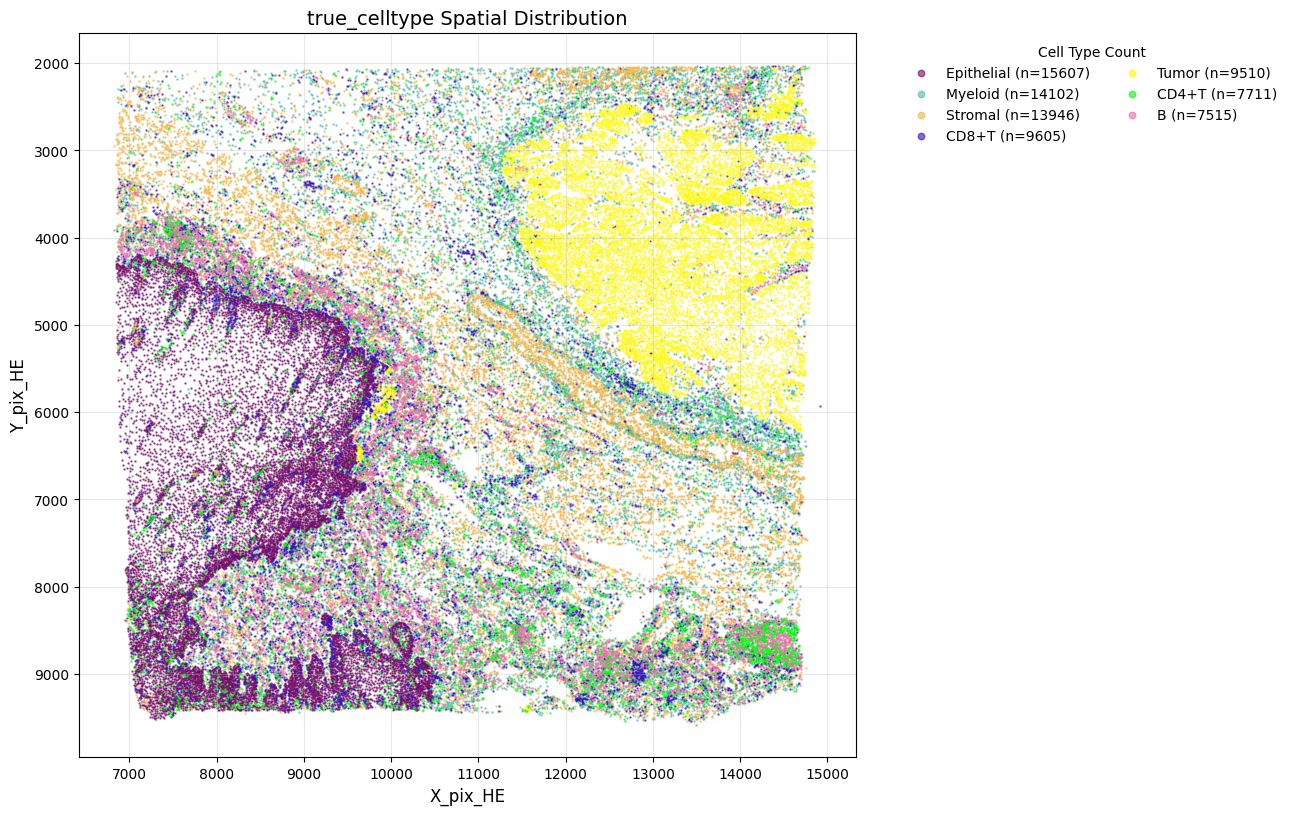

In [28]:
# Optional: uncomment to override default save paths for level1 spatial plots.
# save_path_pred = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/{save_result}/celltype_pred_tumor1_level1_hce.jpg'
# save_path_true = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/{save_result}/celltype_true_tumor1_level1_hce.jpg'

save_path_pred = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/{save_result}/celltype_pred_tumor1_level1_hce.jpg'
save_path_true = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/{save_result}/celltype_true_tumor1_level1_hce.jpg'

plot_level1_spatial_distribution(
    matched_features_path=matched_features_star_path,
    all_preds=all_preds,
    class_names_level1=class_names_level1,
    class_names=class_names,
    y_encoded_f=y_encoded_f,
    y_level1_encoded_f=y_level1_encoded_f,
    plot_celltype_spatial_distribution=plot_celltype_spatial_distribution,
    save_path_pred=save_path_pred,
    save_path_true=save_path_true,
)
print("Saved StarDist level1 predicted/true spatial plots.")


In [ ]:
metrics_acc_star = plot_per_class_accuracy(
    all_labels,
    all_preds,
    class_names_star,
    model=model_star,
    device=device,
    train_dataset=None,
    val_dataset=None,
    input_dim=None,
    best_epoch=None,
    test_acc=all_acc,
    test_macro_f1=all_macro_f1,
    test_weighted_f1=all_weighted_f1,
    model_name="MLP-StarDist-Level2",
    y_sort_by="acc_asc",
    # save_path=f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/{save_result}/acc_tumor1_level2_stardist_hce.pdf',
)

# Level1 from L2 argmax → parent (hierarchy); class_names must match all_preds indices.
metrics_acc_star_l1 = plot_level1_accuracy_from_level2_predictions(
    matched_features_path=matched_features_star_path,
    all_preds=all_preds,
    class_names=class_names_star,
    class_names_level1=class_names_level1,
    y_encoded_f=y_encoded_f,
    y_level1_encoded_f=y_level1_encoded_f,
    plot_per_class_accuracy=plot_per_class_accuracy,
    model=model_star,
    device=device,
    model_name="MLP-StarDist-Level1",
    y_sort_by="acc_asc",
    # save_path=f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/{save_result}/acc_tumor1_level1_stardist_hce.pdf',
)


## plot_level1_accuracy_from_level1_head 的设计是：
## 在 npz 里读 X，用 scaler 变换后跑 model.forward_heads，用 L1 logits 的 argmax 画图，不接受 all_preds
# Level1 from dedicated L1 logits head (forward_heads); needs scaler + X in npz — not all_preds.
metrics_acc_star_l1_head = plot_level1_accuracy_from_level1_head(
    matched_features_path=matched_features_star_path,
    model=model_star,
    device=device,
    scaler=scaler,
    class_names_level1=class_names_level1,
    plot_per_class_accuracy=plot_per_class_accuracy,
    train_dataset=None,
    val_dataset=None,
    input_dim=None,
    best_epoch=None,
    model_name="MLP-StarDist-Level1-head",
    y_sort_by="acc_asc",
    neighbor_index=neighbor_index_star if "neighbor_index_star" in globals() else None,
    # save_path=f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/{save_result}/acc_tumor1_level1_stardist_hce_head.pdf',
)


Computing confusion matrix...


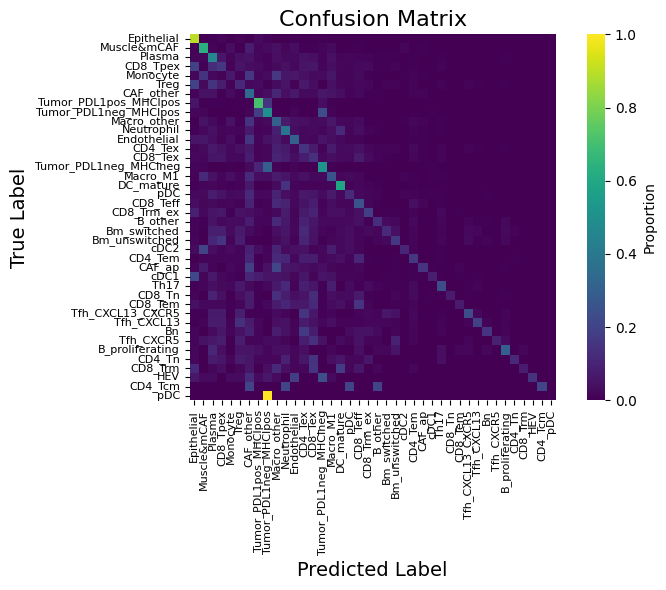

Computing confusion matrix...


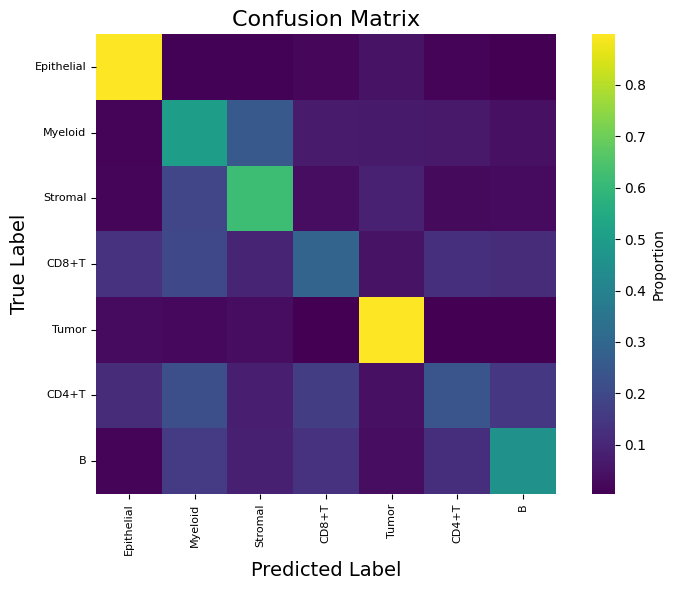

In [36]:
# StarDist prediction heatmaps (confusion matrices): level2 + level1
plot_confusion_matrix(
    all_labels,
    all_preds,
    class_names_star,
    # save_path=f'{therapy_data}/{therapy_model}/{save_result}/conf_matrix_tumor1_level2_stardist_hce.pdf',
)

_loaded_star = np.load(matched_features_star_path, allow_pickle=True)
if "y_level1" in _loaded_star:
    _y_true_l1_raw = _loaded_star["y_level1"]
    _child_to_parent = np.full(len(class_names_star), -1, dtype=np.int64)
    for _l2, _l1 in zip(y_encoded_f, y_level1_encoded_f):
        _l2_i, _l1_i = int(_l2), int(_l1)
        if _child_to_parent[_l2_i] == -1:
            _child_to_parent[_l2_i] = _l1_i
    _preds_l1 = _child_to_parent[np.asarray(all_preds, dtype=np.int64)]

    if getattr(_y_true_l1_raw, "dtype", None) is not None and _y_true_l1_raw.dtype.kind in ["U", "S", "O"]:
        _name_to_idx = {str(c): i for i, c in enumerate(class_names_level1)}
        _y_true_l1 = np.array([_name_to_idx.get(str(v), -1) for v in _y_true_l1_raw], dtype=np.int64)
    else:
        _y_true_l1 = np.asarray(_y_true_l1_raw, dtype=np.int64)

    _n = min(len(_y_true_l1), len(_preds_l1))
    _y_true_l1 = _y_true_l1[:_n]
    _preds_l1 = _preds_l1[:_n]
    _valid = _y_true_l1 >= 0

    if np.any(_valid):
        plot_confusion_matrix(
            _y_true_l1[_valid],
            _preds_l1[_valid],
            class_names_level1,
            # save_path=f'{therapy_data}/{therapy_model}/{save_result}/conf_matrix_tumor1_level1_stardist_hce.pdf',
        )
    else:
        print("Skip level1 StarDist confusion matrix: no valid y_level1 labels.")
else:
    print(f"Skip level1 StarDist confusion matrix: y_level1 not found in {matched_features_star_path}")


In [ ]:
metrics_f1_star = plot_per_class_f1(
    all_labels,
    all_preds,
    class_names_star,
    model=model_star,
    device=device,
    train_dataset=None,
    val_dataset=None,
    input_dim=None,
    best_epoch=None,
    test_acc=all_acc,
    test_macro_f1=all_macro_f1,
    test_weighted_f1=all_weighted_f1,
    y_sort_by="f1_asc", 
    model_name="MLP-StarDist-Level2",
    # save_path=f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/{save_result}/f1_tumor1_level2_stardist_hce.pdf',
)

metrics_f1_star_l1 = plot_level1_f1_from_level2_predictions(
    matched_features_path=matched_features_star_path,
    all_preds=all_preds,
    class_names=class_names_star,
    class_names_level1=class_names_level1,
    y_encoded_f=y_encoded_f,
    y_level1_encoded_f=y_level1_encoded_f,
    plot_per_class_f1=plot_per_class_f1,
    model=model_star,
    device=device,
    y_sort_by="f1_asc", 
    model_name="MLP-StarDist-Level1",
    # save_path=f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/{save_result}/f1_tumor1_level1_stardist_hce.pdf',
)


metrics_acc_star_l1_head = plot_level1_f1_from_level1_head(
    matched_features_path=matched_features_star_path,
    model=model_star,
    device=device,
    scaler=scaler,
    class_names_level1=class_names_level1,
    plot_per_class_f1=plot_per_class_f1,
    train_dataset=None,
    val_dataset=None,
    input_dim=None,
    best_epoch=None,
    y_sort_by="f1_asc",
    model_name="MLP-StarDist-Level1-head",
    neighbor_index=neighbor_index_star if "neighbor_index_star" in globals() else None,
    # save_path=f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/{save_result}/f1_tumor1_level1_stardist_hce_head.pdf',
)


In [ ]:
import numpy as np

_z = np.load(matched_features_star_path)
X_star_scaled = scaler.transform(_z["X"])
probs_l2 = mlp_collect_softmax_probs(
    model_star,
    X_star_scaled,
    device,
    neighbor_index=neighbor_index_star if "neighbor_index_star" in globals() else None,
)

if all_labels is None:
    print("Skip ROC: no ground-truth labels (all_labels is None).")
else:
    m = min(len(probs_l2), len(all_labels))
    roc_info_l2 = plot_multiclass_roc_curves(
        all_labels[:m],
        probs_l2[:m],
        class_names_star,
        figsize=(3.0, 3.0),
        max_curves=len(class_names_star),
        title="StarDist Level2 ROC",
    )
    roc_info_l1 = plot_level1_roc_from_level2_scores(
        matched_features_star_path,
        probs_l2[:m],
        class_names_star,
        class_names_level1,
        y_encoded_f,
        y_level1_encoded_f,
        figsize=(3.0, 3.0),
        title="StarDist Level1 ROC from L2 probs",
    )

    roc_info_l1_head = plot_level1_roc_from_level1_head(
        matched_features_star_path,
        model_star,
        device,
        scaler,
        class_names_level1,
        figsize=(3.0, 3.0),
        n_rows_max=m,
        neighbor_index=neighbor_index_star if "neighbor_index_star" in globals() else None,
        title="StarDist Level1 ROC from L1 head (softmax)",
    )
